# 01 — Exploratory Data Analysis

Dataset: [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data) — daily unit sales, 10 stores × 50 items, 2013–2017.

Goals:
1. Understand overall shape/coverage of the data.
2. Look at trend + seasonality for a representative series.
3. Quantify demand variability across all 500 (store, item) series — this matters later: high-variability SKUs need more safety stock and are the ones where Prophet tuning (vs. defaults) actually moves the needle.
4. Sanity-check stationarity assumptions (informative, even though Prophet doesn't require stationarity the way ARIMA does).

This notebook sets up the *why* behind the modeling choices in `02_prophet_forecasting.ipynb`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

from src.data_loader import get_series, list_series_keys, load_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [2]:
df = load_raw()
print(df.shape)
print(df["date"].min(), "->", df["date"].max())
print(f"{df['store'].nunique()} stores x {df['item'].nunique()} items")
df.head()

(913000, 4)
2013-01-01 00:00:00 -> 2017-12-31 00:00:00
10 stores x 50 items


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Overall sales volume over time

Aggregate across all stores/items to see the macro trend and seasonal pattern before drilling into individual series.

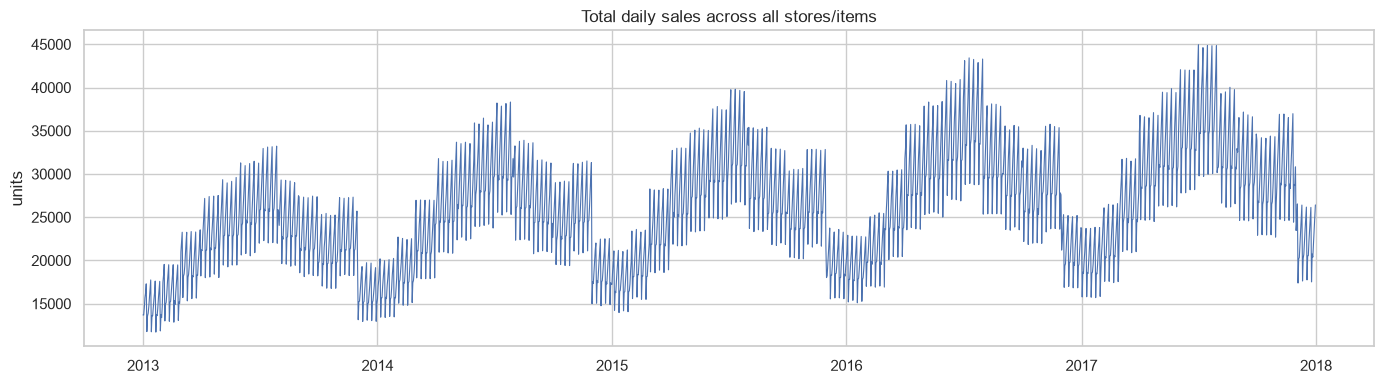

In [3]:
daily_total = df.groupby("date", as_index=False)["sales"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_total["date"], daily_total["sales"], linewidth=0.8)
ax.set_title("Total daily sales across all stores/items")
ax.set_ylabel("units")
plt.tight_layout()

## One representative series in depth

Pick store 1 / item 1 and decompose it into trend, weekly seasonality, and residual using STL. This is the pattern Prophet needs to fit well — a clear upward trend plus strong weekly (and likely annual) seasonality is exactly Prophet's sweet spot.

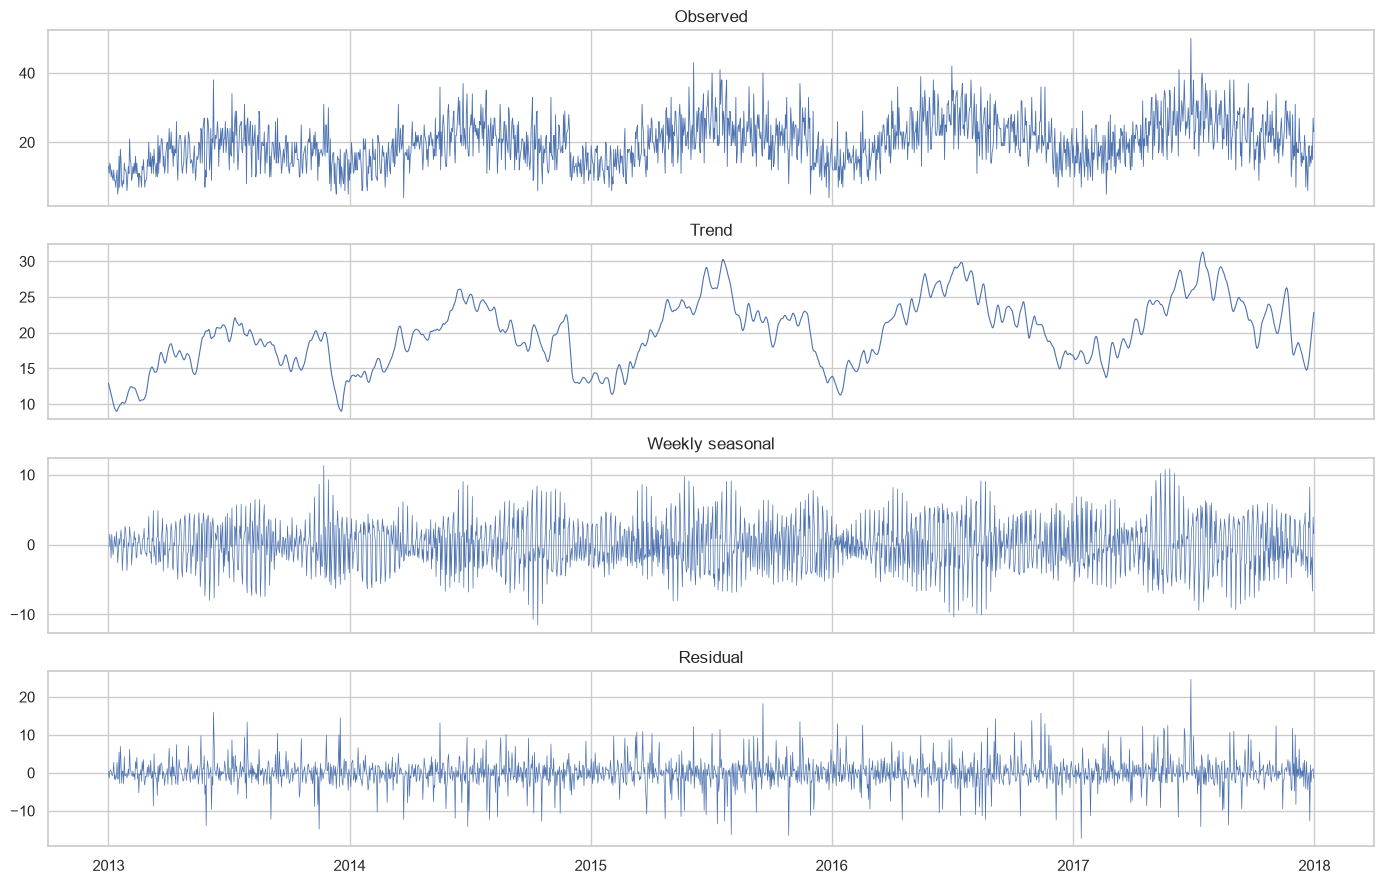

In [4]:
series = get_series(df, store=1, item=1).set_index("ds")

stl = STL(series["y"], period=7, robust=True)  # weekly period for daily data
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(series.index, series["y"], linewidth=0.6); axes[0].set_title("Observed")
axes[1].plot(series.index, res.trend, linewidth=0.8); axes[1].set_title("Trend")
axes[2].plot(series.index, res.seasonal, linewidth=0.5); axes[2].set_title("Weekly seasonal")
axes[3].plot(series.index, res.resid, linewidth=0.5); axes[3].set_title("Residual")
plt.tight_layout()

## Demand variability across all 500 series

Coefficient of variation (std / mean) per (store, item) tells us which SKUs are "easy" (steady, low CV — Prophet defaults will do fine) vs. "hard" (spiky, high CV — where tuning `changepoint_prior_scale`/`seasonality_prior_scale` in notebook 02 actually pays off, and where the inventory simulation in notebook 03 will want more safety stock).

,store,item,mean,std,cv
254,6,5,13.893209,5.187877,0.373411
304,7,5,12.733844,4.731280,0.371552
204,5,5,14.086528,5.157271,0.366114
326,7,27,15.213582,5.478561,0.360110
290,6,41,16.607338,5.902563,0.355419
300,7,1,15.159365,5.374349,0.354523
276,6,27,16.809419,5.921388,0.352266
240,5,41,16.830778,5.922361,0.351877
246,5,47,16.699343,5.873084,0.351696
346,7,47,15.479189,5.432208,0.350936


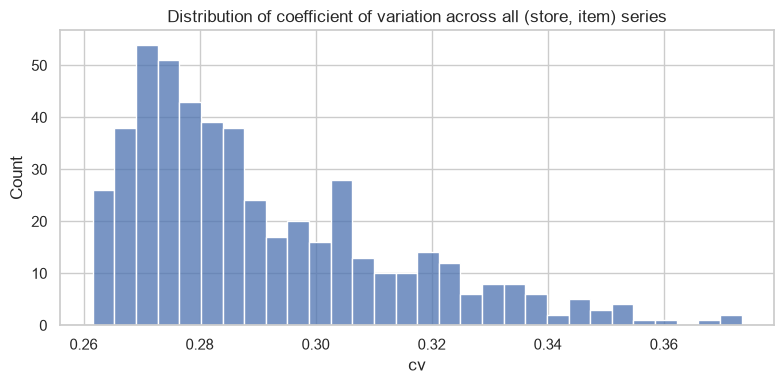

In [5]:
stats = (
    df.groupby(["store", "item"])["sales"]
    .agg(mean="mean", std="std")
    .assign(cv=lambda d: d["std"] / d["mean"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(stats["cv"], bins=30, ax=ax)
ax.set_title("Distribution of coefficient of variation across all (store, item) series")
plt.tight_layout()

stats.sort_values("cv", ascending=False).head(10)

## Stationarity check (informative, not a Prophet prerequisite)

Augmented Dickey-Fuller test on a few series — expect to reject stationarity given the visible trend, which is worth stating explicitly in the write-up as the reason Prophet (trend + seasonality decomposition) is a better fit here than a plain ARMA model without differencing.

In [6]:
sample_keys = list_series_keys(df)[:5]
for store, item in sample_keys:
    s = get_series(df, store, item)["y"]
    stat, pvalue, *_ = adfuller(s)
    print(f"store={store} item={item}: ADF stat={stat:.2f} p-value={pvalue:.4f}")

C:\Users\ntruz\AppData\Local\Temp\ipykernel_2180\780115810.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *_ = adfuller(s)
C:\Users\ntruz\AppData\Local\Temp\ipykernel_2180\780115810.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *_ = adfuller(s)
C:\Users\ntruz\AppData\Local\Temp\ipykernel_2180\780115810.py:4: FutureWarning: adfuller c

store=1 item=1: ADF stat=-3.16 p-value=0.0226
store=1 item=2: ADF stat=-3.16 p-value=0.0222
store=1 item=3: ADF stat=-3.03 p-value=0.0321
store=1 item=4: ADF stat=-2.99 p-value=0.0363


store=1 item=5: ADF stat=-3.28 p-value=0.0158


C:\Users\ntruz\AppData\Local\Temp\ipykernel_2180\780115810.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *_ = adfuller(s)


## Takeaways -> feeding into notebook 02

- Clear multi-year upward trend + weekly and annual seasonality across series -> Prophet is well suited.
- CV varies meaningfully across the 500 series -> tune on a stratified sample (low/medium/high CV) rather than assuming one hyperparameter set fits all, and flag high-CV series as the ones where the inventory simulation matters most.
- Save the variability table for reuse in notebook 03/04 (used to prioritize which SKUs get individual attention).

In [7]:
from src.data_loader import save_processed

save_processed(stats, "series_variability")
stats.to_csv(Path.cwd().parent / "outputs" / "series_variability.csv", index=False)